In [38]:
from typing import Dict, TypedDict, List
from langgraph.graph import StateGraph
import math

In [39]:
class AgentState(TypedDict):
  message: str

def greeting_node(state: AgentState) -> AgentState:
  """ Node to add a greeting message to the state """

  state["message"] = "Hey " + state["message"] + ", how is your day going!"

  return state

def compliment_node(state: AgentState) -> AgentState:
  """ Node to add a compliment to the state """

  state["message"] = state["message"] + ", you're doing a great job!"

  return state

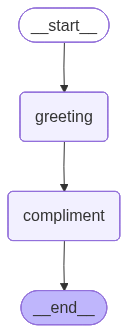

In [40]:
graph = StateGraph(AgentState)

graph.add_node("greeting", greeting_node)
graph.add_node("compliment", compliment_node)
graph.set_entry_point("greeting")
graph.add_edge("greeting", "compliment")
graph.set_finish_point("compliment")

app = graph.compile()
display(app)

In [41]:
result = app.invoke({"message": "Parth"})
result

{'message': "Hey Parth, how is your day going!, you're doing a great job!"}

In [42]:
class ListOpAgentState(TypedDict):
  name: str
  operation: str
  data: List[int]
  result: str

In [43]:
def compute_list(state: ListOpAgentState) -> ListOpAgentState:
  """ Node to perform + and * operations on list data """

  if state["operation"] == "+":
    state["result"] = "Hi " + state["name"] + ", the result for your operation " + state["operation"] + " is: " + str(sum(state["data"]))
  elif state["operation"] == "*":
    state["result"] = "Hi " + state["name"] + ", the result for your operation " + state["operation"] + " is: " + str(math.prod(state["data"]))
  else:
    state["result"] = "Hi " + state["name"] + ", the operation you selected is not supported. \nPlease select '+' or '*'."

  return state

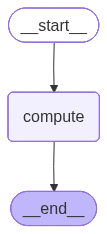

In [44]:
list_op_graph = StateGraph(ListOpAgentState)

list_op_graph.add_node("compute", compute_list)
list_op_graph.set_entry_point("compute")
list_op_graph.set_finish_point("compute")

list_app = list_op_graph.compile()
display(list_app)

In [45]:
list_result = list_app.invoke({"name": "Parth", "operation": "+", "data": [12, 6, 3, 86]})

In [46]:
list_result

{'name': 'Parth',
 'operation': '+',
 'data': [12, 6, 3, 86],
 'result': 'Hi Parth, the result for your operation + is: 107'}

In [47]:
from langgraph.graph import START, END

In [53]:
class MultiOpAgentState(TypedDict):
  number1: int
  number2: int
  operator1: str
  number3: int
  number4: int
  operator2: str
  final1: int
  final2: int

In [63]:
def add_node(state: MultiOpAgentState) -> MultiOpAgentState:
  """ Node to add first two values """

  state['final1'] = state["number1"] + state["number2"]

  return state

def subtract_node(state: MultiOpAgentState) -> MultiOpAgentState:
  """ Node to subtract first two values """

  state['final1'] = state["number1"] - state["number2"]

  return state

def add_node2(state: MultiOpAgentState) -> MultiOpAgentState:
  """ Node to add second two values """

  state['final2'] = state["number3"] + state["number4"]

  return state

def subtract_node2(state: MultiOpAgentState) -> MultiOpAgentState:
  """ Node to subtract second two values """

  state['final2'] = state["number3"] - state["number4"]

  return state

def router(state: MultiOpAgentState) -> str:
  """ Router node for first operation """

  if state["operator1"] == "+":
    return "addition_operation"
  elif state["operator1"] == "-":
    return "subtraction_operation"

def router2(state: MultiOpAgentState) -> str:
  """ Router node for second operation """

  if state["operator2"] == "+":
    return "addition_operation2"
  elif state["operator2"] == "-":
    return "subtraction_operation2"

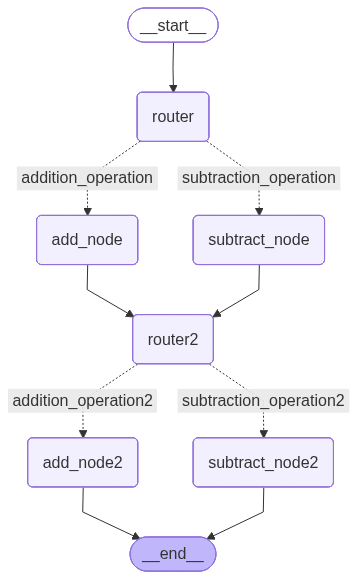

In [68]:
multi_graph = StateGraph(MultiOpAgentState)

multi_graph.add_node("add_node", add_node)
multi_graph.add_node("add_node2", add_node2)
multi_graph.add_node("subtract_node", subtract_node)
multi_graph.add_node("subtract_node2", subtract_node2)
multi_graph.add_node("router", lambda state: state)
multi_graph.add_node("router2", lambda state: state)

multi_graph.add_edge(START, "router")
multi_graph.add_conditional_edges(
    "router",
    router,
    {
        "addition_operation": "add_node",
        "subtraction_operation": "subtract_node"
    }
)
multi_graph.add_edge("add_node", "router2")
multi_graph.add_edge("subtract_node", "router2")
multi_graph.add_conditional_edges(
    "router2",
    router2,
    {
        "addition_operation2": "add_node2",
        "subtraction_operation2": "subtract_node2"
    }
)
multi_graph.add_edge("add_node2", END)
multi_graph.add_edge("subtract_node2", END)

multi_app = multi_graph.compile()
display(multi_app)

In [69]:
multi_res = multi_app.invoke({
    "number1": 10,
    "number2": 5,
    "operator1": "-",
    "number3": 7,
    "number4": 2,
    "operator2": "+"
})

In [71]:
print(multi_res)

{'number1': 10, 'number2': 5, 'operator1': '-', 'number3': 7, 'number4': 2, 'operator2': '+', 'final1': 5, 'final2': 9}
